In [2]:
import time
import numpy as np
import psi4
%matplotlib inline
import matplotlib.pyplot as plt
import pickle
import os 

In [2]:
build_superfunctional = psi4.driver.dft.build_superfunctional

def build_orbitals(diag, A, nel, level_shift):
    
    diag = psi4.core.Matrix.from_array(diag)
    A = psi4.core.Matrix.from_array(A)
    
    Fp = psi4.core.triplet(A, diag, A, True, False, True)
    
    if level_shift > 0.0:
        Fp_np = Fp.np
        for i in range(1, Fp_np.shape[0]):
            Fp_np[i, i] += level_shift
        Fp = psi4.core.Matrix.from_array(Fp_np)

    nbf = A.shape[0]
    Cp = psi4.core.Matrix(nbf, nbf)
    eigvecs = psi4.core.Vector(nbf)
    
    Fp.diagonalize(Cp, eigvecs, psi4.core.DiagonalizeOrder.Ascending)

    C = psi4.core.doublet(A, Cp, False, False)
    
    Cocc = psi4.core.Matrix(nbf, 1)    
    Cocc.np[:] = np.sqrt(nel) * C.np[:, :1]

    D = psi4.core.doublet(Cocc, Cocc, False, True)   

    return C, Cocc, D, eigvecs

def ks_solver(maxiter, alias1, alias2, lam, mol, damp, shift, FA=True, READ=True):

    E_conv = 1.0e-6
    D_conv = 1.0e-6
    
    wfn = psi4.core.Wavefunction.build(mol, psi4.core.get_global_option("BASIS"))
    mints = psi4.core.MintsHelper(wfn.basisset())
    S = np.asarray(mints.ao_overlap())
    
    nbf = wfn.nso()
    nel = wfn.nalpha() + wfn.nbeta()
    ndocc = max(wfn.nalpha(), wfn.nalpha())
    nalpha = wfn.nalpha()
    nbeta = wfn.nbeta()
    
    print('\nNumber of electrons: %d' % nel)
    print('Number of double occupied orbitals: %d' % ndocc)
    print('Number of basis functions:   %d' % nbf)
    
    sup1 = build_superfunctional(alias1, False)[0]
    sup1.set_deriv(1)
    sup1.allocate()
    
    sup2 = build_superfunctional(alias2, False)[0]
    sup2.set_deriv(1)
    sup2.allocate()
    
    vname = "UV"
    Vpot = psi4.core.VBase.build(wfn.basisset(), sup1, vname)
    Vpot.initialize()
    
    Vpot_W = psi4.core.VBase.build(wfn.basisset(), sup2, vname)
    Vpot_W.initialize()
    
    V = np.asarray(mints.ao_potential())
    T = np.asarray(mints.ao_kinetic())
    I = np.asarray(mints.ao_eri())
    H = T + V
    
    A = mints.ao_overlap()
    A.power(-0.5, 1.e-14)
    A = np.asarray(A)
    
    Ca, Cocca, Da, eigsa = build_orbitals(H, A, nalpha, shift)
    Cb, Coccb, Db, eigsb = build_orbitals(H, A, nbeta, shift)
    if READ:
        Da = D_GUESS_A
        Db = D_GUESS_B
    
    diisA_obj = psi4.p4util.solvers.DIIS(max_vec=3, removal_policy="oldest")
    diisB_obj = psi4.p4util.solvers.DIIS(max_vec=3, removal_policy="oldest")
    
    E = 0.0
    Enuc = mol.nuclear_repulsion_energy()
    Eold = 0.0
    
    print('\nStarting SCF iterations:')
    t = time.time()
    conv_list = []
    drms_list = []
   
    print("\n    Iter            Energy             IP         Delta E        D RMS\n")
    for SCF_ITER in range(1, maxiter + 1):
    
        Ja = np.einsum('pqrs,rs->pq', I, Da.np, optimize=True)
        Jb = np.einsum('pqrs,rs->pq', I, Db.np, optimize=True)
        if FA:
            Fa = H + Ja + Jb - 4 * 0.25 * ( Ja / nalpha )
            if nbeta == 0:
                Fb = H + Ja + Jb
            else:
                Fb = H + Ja + Jb - 4 * 0.25 * ( Jb / nbeta )
        else:
            Fa = H + Ja + Jb
            Fb = H + Ja + Jb 

        Da_old_np = Da.np.copy()
        Db_old_np = Db.np.copy()

        Vpot.set_D([ Da , Db ])
        Va = psi4.core.Matrix(nbf, nbf)
        Vb = psi4.core.Matrix(nbf, nbf)
        Vpot.compute_V([ Va , Vb ])
        tfd_e = Vpot.quadrature_values()['FUNCTIONAL']

        Vpot_W.set_D([ Da , Db ])
        Va_W = psi4.core.Matrix(nbf, nbf)
        Vb_W = psi4.core.Matrix(nbf, nbf)
        Vpot_W.compute_V([ Va_W , Vb_W ])
        vw_e = Vpot_W.quadrature_values()['FUNCTIONAL']

        Vxca = ( Va.np + (lam - 1) * Va_W.np )
        Vxcb = ( Vb.np + (lam - 1) * Vb_W.np )
        e_xc = ( tfd_e + ( lam - 1 ) * vw_e ) 
        Fa += Vxca
        Fb += Vxcb

        Fa = psi4.core.Matrix.from_array(Fa)
        Fb = psi4.core.Matrix.from_array(Fb)
        S = psi4.core.Matrix.from_array(S)
        A = psi4.core.Matrix.from_array(A)
        diisA_e = psi4.core.triplet(Fa, Da, S, False, False, False)
        diisA_e.subtract(psi4.core.triplet(S, Da, Fa, False, False, False))
        diisA_e = psi4.core.triplet(A, diisA_e, A, False, False, False)
        diisB_e = psi4.core.triplet(Fb, Db, S, False, False, False)
        diisB_e.subtract(psi4.core.triplet(S, Db, Fb, False, False, False))
        diisB_e = psi4.core.triplet(A, diisB_e, A, False, False, False)

        diisA_obj.add(Fa, diisA_e)
        diisB_obj.add(Fb, diisB_e)

        dRMS = 0.5 * ( diisA_e.rms() + diisB_e.rms() ) 

        SCF_E = np.einsum('pq,pq->', (Da.np + Db.np), H, optimize=True)
        SCF_E += np.einsum('pq,pq->', Da.np, Fa.np - Vxca, optimize=True)
        SCF_E += np.einsum('pq,pq->', Db.np, Fb.np - Vxcb, optimize=True)
        SCF_E *= 0.5
        SCF_E += e_xc
        SCF_E += Enuc

        print('SCF Iter%3d: % 18.8f   % 11.6f   % 1.5E   %1.5E'
              % (SCF_ITER, SCF_E, e_xc, (SCF_E - Eold), dRMS))
        
        # if dRMS < 1.0E-5:
        #     shift = 0
        # if dRMS > 1.0E-5:
        #     shift = 0.6 
            
        # if abs(SCF_E - Eold) < 1.0E-1:
        #     damp = 0.99
        # if abs(SCF_E - Eold) > 1.0E-1:
        #     damp = 0.9
        
        conv_list.append(np.log10(abs(SCF_E - Eold)))
        drms_list.append(np.log10(dRMS))
        
        if (abs(SCF_E - Eold) < E_conv) and (dRMS < D_conv):
            break
    
        Eold = SCF_E
        
        Fa = diisA_obj.extrapolate()
        Fb = diisB_obj.extrapolate()
        Ca, CoccA, Da, eigsA = build_orbitals(Fa, A, nalpha, shift)
        Cb, CoccB, Db, eigsB = build_orbitals(Fb, A, nbeta, shift)
            
        Da.np[:] = (damp * Da_old_np) + ((1.0 - damp) * Da.np)
        Db.np[:] = (damp * Db_old_np) + ((1.0 - damp) * Db.np)
        
        if SCF_ITER == maxiter:
            SCF_Da = Da
            SCF_Db = Db
            print("\nMaximum number of SCF cycles exceeded. The final values are printed")
            return SCF_E, SCF_Da, SCF_Db, conv_list, SCF_ITER, drms_list
            raise Exception("Maximum number of SCF cycles exceeded.")
    
    SCF_Da = Da
    SCF_Db = Db
    
    print('\nTotal time for SCF iterations: %.3f seconds ' % (time.time() - t))

    return SCF_E, SCF_Da, SCF_Db, conv_list, SCF_ITER, drms_list

In [74]:
psi4.core.clean_options()
psi4.core.clean()
psi4.core.set_output_file('output.dat', False)

mol = psi4.geometry("""
units bohr
0 1
Ne
symmetry c1
""")
psi4.set_options({'basis': 'UGBS_S',
                  'scf_type': 'PK',
                  'REFERENCE': 'UKS',
                 'DFT_SPHERICAL_POINTS': 974,
                  'DFT_RADIAL_POINTS': 999})

TFD = {
    "name": "TFD",
    "x_functionals": {"GGA_X_PBE": {"alpha": 0.00}},
    "c_functionals": {"LDA_K_TF": {"alpha": 1.00}}
}
vW = {
    "name": "vW",
    "x_functionals": {"LDA_X": {"alpha": 0.0}},
    "c_functionals": {"GGA_K_VW": {"alpha": 1.0}}
}

shift = 0.0
damp = 0.99

SCF_E, Da, Db, conv_list, SCF_ITER, drms_list = ks_solver(1000, TFD, vW, 1.0, mol, damp, shift, FA=True, READ=True)
print('\nFinal SCF energy: %.4f hartree' % SCF_E)


Number of electrons: 10
Number of double occupied orbitals: 5
Number of basis functions:   31

Starting SCF iterations:

    Iter            Energy             IP         Delta E        D RMS

SCF Iter  1:       -82.79010866     52.369655   -8.27901E+01   7.16063E-05
SCF Iter  2:       -82.79010866     52.369656   -5.68434E-14   7.08901E-05
SCF Iter  3:       -82.79010866     52.369634    1.56035E-11   7.01877E-05
SCF Iter  4:       -82.79010866     52.369634   -1.98952E-13   6.94858E-05
SCF Iter  5:       -82.79010866     52.369635   -2.41585E-13   6.87910E-05
SCF Iter  6:       -82.79010866     52.369635   -4.40536E-13   6.81027E-05
SCF Iter  7:       -82.79010866     52.369636   -4.83169E-13   6.74217E-05
SCF Iter  8:       -82.79010866     52.369636    1.98952E-13   6.67477E-05
SCF Iter  9:       -82.79010866     52.369636   -4.26326E-13   6.60802E-05
SCF Iter 10:       -82.79010866     52.369636   -2.27374E-13   6.54194E-05
SCF Iter 11:       -82.79010866     52.369636   -3.41061

/var/folders/8h/bqf7kp1s77g79xb5tdv9n7lh0000gn/T/ipykernel_3102/2023003261.py:164: RuntimeWarning: divide by zero encountered in log10
  conv_list.append(np.log10(abs(SCF_E - Eold)))


SCF Iter145:       -82.79010866     52.369650   -1.98952E-13   1.68468E-05
SCF Iter146:       -82.79010866     52.369649    2.84217E-14   1.66785E-05
SCF Iter147:       -82.79010866     52.369650   -2.84217E-14   1.65117E-05
SCF Iter148:       -82.79010866     52.369650   -1.70530E-13   1.63466E-05
SCF Iter149:       -82.79010866     52.369650    8.52651E-14   1.61832E-05
SCF Iter150:       -82.79010866     52.369650    0.00000E+00   1.60214E-05
SCF Iter151:       -82.79010866     52.369650   -1.70530E-13   1.58611E-05
SCF Iter152:       -82.79010866     52.369650   -1.42109E-13   1.57025E-05
SCF Iter153:       -82.79010866     52.369650    4.26326E-14   1.55455E-05
SCF Iter154:       -82.79010866     52.369650   -1.70530E-13   1.53899E-05
SCF Iter155:       -82.79010866     52.369650    0.00000E+00   1.52360E-05
SCF Iter156:       -82.79010866     52.369650    1.42109E-14   1.50838E-05
SCF Iter157:       -82.79010866     52.369650    1.42109E-14   1.49329E-05
SCF Iter158:       -82.79

In [73]:
D_GUESS_A, D_GUESS_B = Da, Db

In [3]:
psi4.core.set_output_file('output.dat', False)

mol = psi4.geometry("""
units bohr
0 1
Be
symmetry c1
""")

rhf_e, rhf_wfn = psi4.energy('HF/UGBS_S', return_wfn=True)

In [18]:
FILE_PATH = r'/Users/ivanbosko/Desktop/UWO/Thesis/Manuscripts/FA_in_LPS/Calculations/tfwpbe_scf_atom_densities.pkl'
if os.path.exists(FILE_PATH):
    with open(FILE_PATH, 'rb') as f:
        main_dict = pickle.load(f)
    print(f"Loaded existing database. Keys: {list(main_dict.keys())}")
else:
    main_dict = {}
    print("Created new database.")

Loaded existing database. Keys: ['1.0', '0.2', '0.333333', '0.186', '0.166666', '0.111111']


In [19]:
Da = main_dict['0.2']['Be']['Da']
Db = main_dict['0.2']['Be']['Db']
D = Da + Db

In [24]:
FILE_PATH = r'/Users/ivanbosko/Desktop/UWO/Thesis/Manuscripts/FA_in_LPS/Calculations/be_sic_scf_densities.pkl'
if os.path.exists(FILE_PATH):
    with open(FILE_PATH, 'rb') as f:
        main_dict = pickle.load(f)

In [25]:
Da = main_dict['Da']
Db = main_dict['Db']
D = Da + Db

In [4]:
D = rhf_wfn.Da().np + rhf_wfn.Db().np

In [20]:
np.set_printoptions(suppress=True, precision=10, floatmode='fixed')
D = Da + Db
print(D[10])

[ 0.0000000130 -0.0000000076  0.0000000430  0.0000000247  0.0000001383
  0.0000002361  0.0000006250  0.0000013457  0.0000031103  0.0000067692
  0.0000144363  0.0000288963  0.0000541379  0.0000932484  0.0001487055
  0.0002202883  0.0003101335  0.0004176685  0.0005528081  0.0007095337
  0.0009124071  0.0011142017  0.0013894830  0.0015300051  0.0018828773
  0.0015594581  0.0022153867  0.0012076135  0.0027076480  0.0004128885
 -0.0000281430]


In [5]:
def prim_gauss(a, d, r):
    g = ( 2 * a / np.pi ) ** ( 3 / 4 ) * np.exp( - a * r ** 2 )
    return d * g

In [6]:
r = np.arange(0.0, 10.01, 0.01)
np.set_printoptions(suppress=True, precision=2, floatmode='fixed')
print(r)

[ 0.00  0.01  0.02 ...  9.98  9.99 10.00]


In [7]:
a_list = [
    11387194.5850786, 5815282.94190191, 2969784.65079439, 1516627.98873367,
    774520.959152738, 395537.152566831, 201995.358823884, 103156.238855453,
    52680.4659115021, 26903.1860742975, 13739.0854166734, 7016.36109438299,
    3583.15866840945, 1829.86962476550, 934.489134729210, 477.230689612032,
    243.715119463182, 124.461944187287, 63.5609952513411, 32.4597220758638,
    16.5767315800501, 8.46550778330153, 4.32321786011102, 2.20780762884063,
    1.12749685157938, 0.575797063890464, 0.294051604951678, 0.150168091845475,
    7.668876968794860e-002, 3.916389509898707e-002, 2.000046011385546e-002
]

In [54]:
# UGBS Be
a_list = [
    201995.358823884, 103156.238855453,
    52680.4659115021, 26903.1860742975, 13739.0854166734, 7016.36109438299,
    3583.15866840945, 1829.86962476550, 934.489134729210, 477.230689612032,
    243.715119463182, 124.461944187287, 63.5609952513411, 32.4597220758638,
    16.5767315800501, 8.46550778330153, 4.32321786011102, 2.20780762884063,
    1.12749685157938, 0.575797063890464, 0.294051604951678, 0.150168091845475,
    7.668876968794860e-002, 3.916389509898707e-002, 2.000046011385546e-002
]

In [26]:
density = 0
for i in range(0, len(a_list)):
    for j in range(0, len(a_list)):
        density += D[i,j] * prim_gauss(a_list[i], 1, r) * prim_gauss(a_list[j], 1, r)

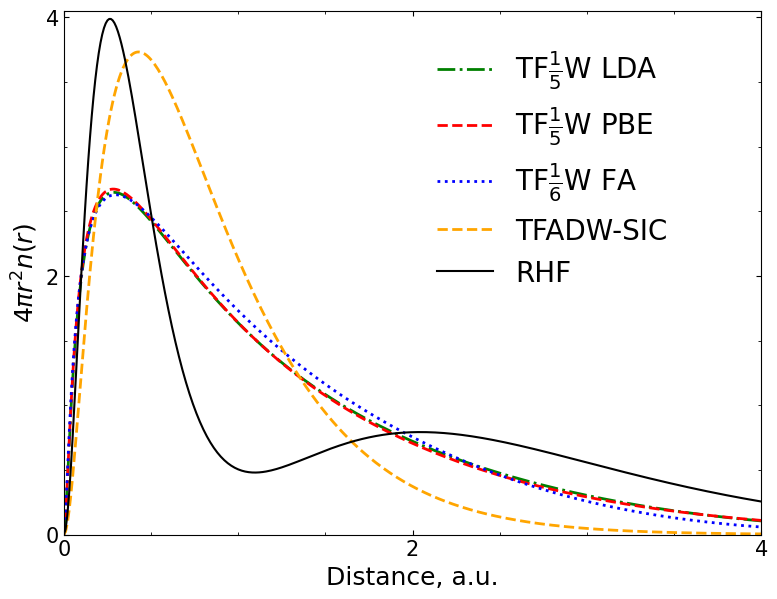

In [29]:
fig, ax = plt.subplots(figsize=(9, 6.8))
ax.plot(r, 4 * np.pi * r **2 * density_lda, label='TF$\\frac{1}{5}$W LDA', color='green', linestyle='-.', linewidth=2)
ax.plot(r, 4 * np.pi * r **2 * density_pbe, label='TF$\\frac{1}{5}$W PBE', color='red', linestyle='--', linewidth=2)
ax.plot(r, 4 * np.pi * r **2 * density_fa, label='TF$\\frac{1}{6}$W FA', color='blue', linestyle=':', linewidth=2)
ax.plot(r, 4 * np.pi * r **2 * density_sic, label='TFADW-SIC', color='orange', linestyle='--', linewidth=2)
ax.plot(r, 4 * np.pi * r **2 * density_hf, label='RHF', color='black', linestyle='-', linewidth=1.5)

ax.legend(loc='center', bbox_to_anchor=(0.70, 0.70), fontsize=20, frameon=False)
ax.tick_params(axis='both', direction='in', top=True, right=True)
ax.minorticks_on()
ax.tick_params(which='minor', axis='both', direction='in', top=True, right=True)
ax.set_xlabel("Distance, a.u.", fontsize=18)
ax.set_ylabel("4$\\pi r^2 n(r)$", fontsize=18)
ax.axis([0.0, 4, 0, 4.05])
ax.set_xticks(np.arange(0.0, 6.0, 2.0))
ax.tick_params(axis='x', labelsize=15)
ax.set_yticks(np.arange(0.0, 5.0, 2.0))
ax.tick_params(axis='y', labelsize=15)

# axins = ax.inset_axes([0.45, 0.45, 0.5, 0.5])
# axins.plot(r, 4 * np.pi * r **2 * density_lda, color='green', linestyle='-.', linewidth=2)
# axins.plot(r, 4 * np.pi * r **2 * density_pbe, color='red', linestyle='--', linewidth=2)
# axins.plot(r, 4 * np.pi * r **2 * density_fa, color='blue', linestyle=':', linewidth=2)
# axins.plot(r, 4 * np.pi * r **2 * density_hf, color='black', linestyle='-', linewidth=2)
# axins.set_xlim(6, 8)
# axins.set_ylim(0, 0.01)
# axins.set_xticks(np.arange(6.0, 9.0, 1.0))
# axins.set_yticks(np.arange(0.0, 0.02, 0.01))
# axins.tick_params(axis='both', labelsize=13, direction='in')

plt.savefig(r'/Users/ivanbosko/Desktop/UWO/Thesis/Manuscripts/FA_in_LPS/LATEX/Figures/be_density_2.png', format='png')

In [13]:
density_fa = density

In [9]:
density_hf = density

In [21]:
density_pbe = density

In [17]:
density_lda = density

In [46]:
density_hf_s = density

In [28]:
density_sic = density

In [62]:
atom_scf_densities_dict = {
    'BASIS': 'UGBS_S',
    'DFT_SPHERICAL_POINTS': 974,
    'DFT_RADIAL_POINTS': 999,
    'R': r, 
    'LDA': density_lda,
    'PBE': density_pbe,
    'FA': density_fa,
}

In [ ]:
scf_densities_dict = {'R': r, 
                      'LDA': density_lda,
                      'PBE': density_pbe,
                      'FA': density_fa,}

atom_scf_densities_dict['H'] = scf_densities_dict

# with open(r'/Users/ivanbosko/Desktop/UWO/Thesis/Manuscripts/FA in OFDFT/Calculations/pbe_scf_atom_densities.pkl', 'wb') as f:
#     pickle.dump(atom_scf_densities_dict, f)

In [63]:
with open(r'/Users/ivanbosko/Desktop/UWO/Thesis/Manuscripts/FA_in_LPS/Calculations/scf_ne_densities.pkl', 'wb') as f:
    pickle.dump(atom_scf_densities_dict, f)

(np.float64(5.0), np.float64(6.0), np.float64(0.0), np.float64(0.0003))

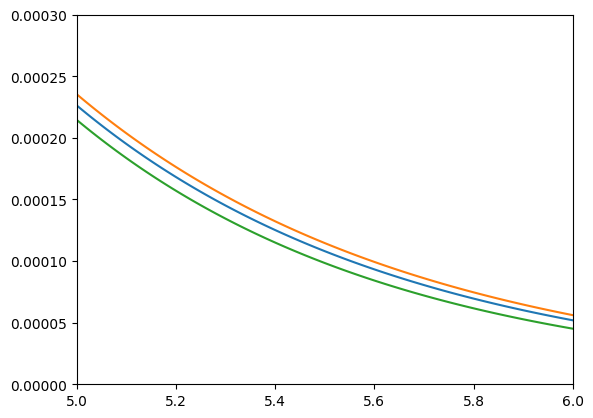

In [107]:
plt.plot(r, density_lda)
plt.plot(r, density_pbe)
plt.plot(r, density_fa)
plt.axis([5.0, 6.0, 0.0, 0.0003])